## IMPORTING LIBRARY AND LOADING DATASET

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("creditcard.csv")

## DATA UNDERSTANDING

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


## DATA CLEANING

In [11]:
print(df['Class'].value_counts())

print("\nPercentage Distribution")

print(df['Class'].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [12]:
duplicates = df[df.duplicated()]

print("Duplicate Rows:", duplicates.shape[0])

duplicates.head()

Duplicate Rows: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [13]:
duplicates['Class'].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [14]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (284807, 31)
After: (283726, 31)


In [15]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

## EXPLORATORY DATA ANALYSIS (EDA)

In [16]:
print(df['Amount'].describe())

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


In [17]:
fraud = df[df['Class']==1]
normal = df[df['Class']==0]

print("Fraud Transactions")
print(fraud['Amount'].describe())

print("\nNormal Transactions")
print(normal['Amount'].describe())

Fraud Transactions
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal Transactions
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64


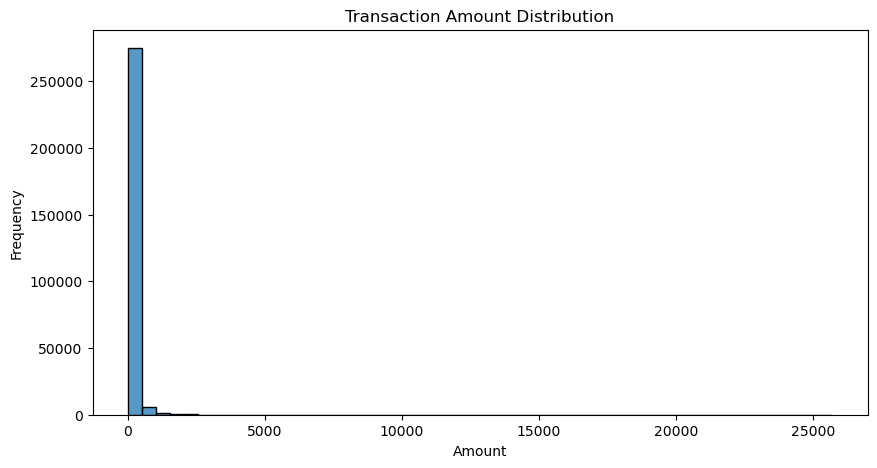

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

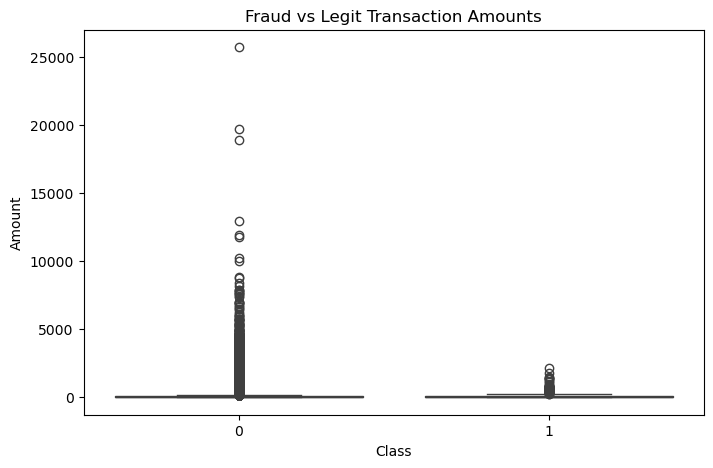

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title("Fraud vs Legit Transaction Amounts")
plt.show()

In [20]:
df['Hour'] = (df['Time']//3600)%24

df['Amount_Log'] = np.log1p(df['Amount'])

In [21]:
df[['Time','Hour','Amount','Amount_Log']].head()

,Time,Hour,Amount,Amount_Log
0,0.0,0.0,149.62,5.014760
1,0.0,0.0,2.69,1.305626
2,1.0,0.0,378.66,5.939276
3,1.0,0.0,123.50,4.824306
4,2.0,0.0,69.99,4.262539


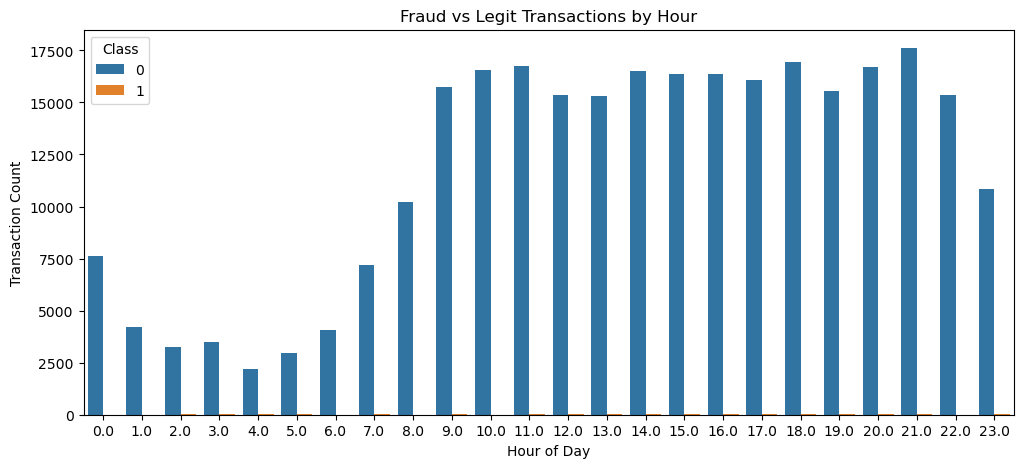

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Hour',
    hue='Class',
    data=df
)

plt.title("Fraud vs Legit Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")

plt.show()

In [23]:
fraud_by_hour = df[df['Class']==1]['Hour'].value_counts().sort_index()

print(fraud_by_hour)

Hour
0.0      6
1.0     10
2.0     48
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    28
18.0    28
19.0    19
20.0    18
21.0    16
22.0     9
23.0    17
Name: count, dtype: int64


In [24]:
corr = df.corr()

fraud_corr = corr['Class'].sort_values(ascending=False)

print(fraud_corr.head(15))

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
Name: Class, dtype: float64


## FEATURE ENGINEERING

In [25]:
df['Hour'] = (df['Time'] // 3600) % 24

df['Day_Part'] = pd.cut(
    df['Hour'],
    bins=[-1,6,12,18,24],
    labels=['Night','Morning','Afternoon','Evening']
)

In [26]:
df[['Time','Hour','Day_Part']].head()

,Time,Hour,Day_Part
0,0.0,0.0,Night
1,0.0,0.0,Night
2,1.0,0.0,Night
3,1.0,0.0,Night
4,2.0,0.0,Night


In [27]:
df['Amount_Log'] = np.log1p(df['Amount'])

In [28]:
df[['Amount','Amount_Log']].head()

,Amount,Amount_Log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Scaled_Amount'] = scaler.fit_transform(
    df[['Amount']]
)

df['Scaled_Time'] = scaler.fit_transform(
    df[['Time']]
)

In [30]:
df[['Amount','Scaled_Amount','Time','Scaled_Time']].head()

,Amount,Scaled_Amount,Time,Scaled_Time
0,149.62,0.244200,0.0,-1.996823
1,2.69,-0.342584,0.0,-1.996823
2,378.66,1.158900,1.0,-1.996802
3,123.50,0.139886,1.0,-1.996802
4,69.99,-0.073813,2.0,-1.996781


## PREPARING DATA FOR MODELS

In [31]:
X = df.drop(['Class', 'Day_Part'], axis=1)

y = df['Class']

print(X.shape)
print(y.shape)

(283726, 34)
(283726,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (226980, 34)
Testing Set : (56746, 34)


In [33]:
print("Training Distribution")
print(y_train.value_counts())

print("\nTesting Distribution")
print(y_test.value_counts())

Training Distribution
Class
0    226602
1       378
Name: count, dtype: int64

Testing Distribution
Class
0    56651
1       95
Name: count, dtype: int64


## Models


### MODEL 1: LOGISTIC REGRESSION

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.9991541254009093
Precision: 0.8615384615384616
Recall   : 0.5894736842105263
F1 Score : 0.7


#### Confusion Matrix

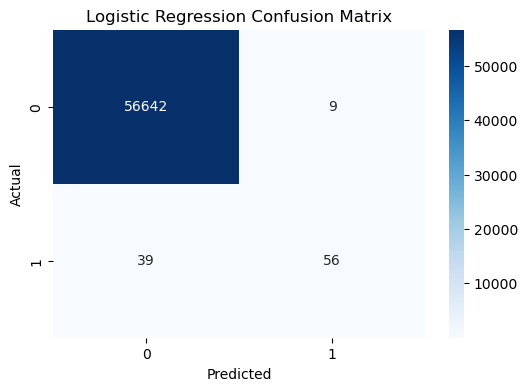

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### MODEL 2: DECISION TREE

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.9989426567511367
Precision: 0.6842105263157895
Recall   : 0.6842105263157895
F1 Score : 0.6842105263157895


### MODEL 3: RANDOM FOREST

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9995065731505305
Precision: 0.971830985915493
Recall   : 0.7263157894736842
F1 Score : 0.8313253012048193


### MODEL 4: XGBOOST

In [42]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(scale_pos_weight)

599.4761904761905


In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [44]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

Accuracy : 0.9993479716632009
Precision: 0.8152173913043478
Recall   : 0.7894736842105263
F1 Score : 0.8021390374331551


## Feature Importance Analysis

In [45]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top_features = feature_importance.sort_values(
    ascending=False
).head(15)

print(top_features)

V17    0.172366
V12    0.138968
V14    0.104269
V16    0.083989
V11    0.072398
V10    0.056565
V9     0.037771
V7     0.028191
V4     0.025375
V18    0.021062
V26    0.018099
V3     0.014890
V21    0.013743
V1     0.013668
V6     0.013580
dtype: float64


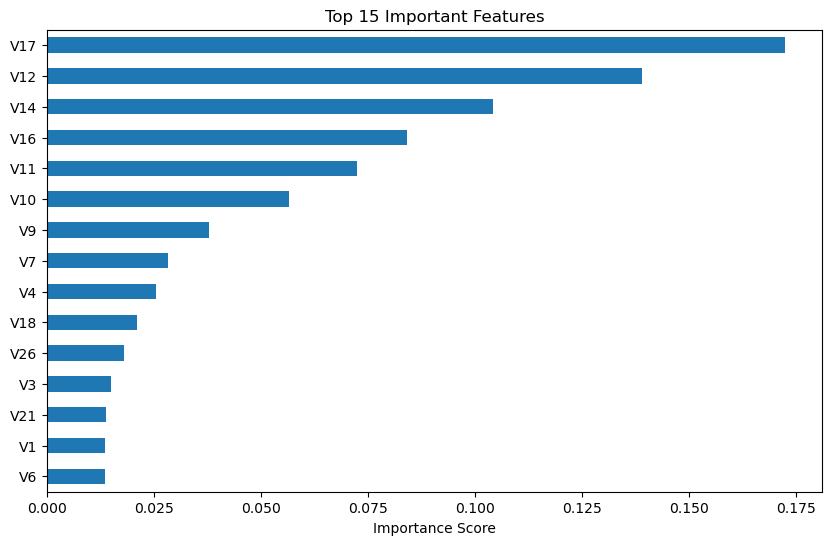

In [46]:
plt.figure(figsize=(10,6))

top_features.sort_values().plot(
    kind='barh'
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")

plt.show()

## Balanced Random Forest Model

In [47]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_balanced_pred))
print("Precision:", precision_score(y_test, rf_balanced_pred))
print("Recall   :", recall_score(y_test, rf_balanced_pred))
print("F1 Score :", f1_score(y_test, rf_balanced_pred))

Accuracy : 0.9994360836006062
Precision: 0.9565217391304348
Recall   : 0.6947368421052632
F1 Score : 0.8048780487804879


## Final Results

In [48]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, rf_balanced_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, rf_balanced_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, rf_balanced_pred),
        recall_score(y_test, xgb_pred)
        
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, rf_balanced_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results[["Accuracy", "Precision", "Recall", "F1 Score"]] = (
    results[["Accuracy", "Precision", "Recall", "F1 Score"]] * 100
).round(2)


best_model = results.loc[results["F1 Score"].idxmax(), "Model"]

print("\nBest Performing Model:", best_model)
results.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1 Score"],
    color="blue"
)


Best Performing Model: Random Forest


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,99.920000,86.150000,58.950000,70.000000
1,Decision Tree,99.890000,68.420000,68.420000,68.420000
2,Random Forest,99.950000,97.180000,72.630000,83.130000
3,Balanced Random Forest,99.940000,95.650000,69.470000,80.490000
4,XGBoost,99.930000,81.520000,78.950000,80.210000
